<img src="https://full-stack-assets.s3.eu-west-3.amazonaws.com/M08-deep-learning/AT%26T_logo_2016.svg" alt="AT&T LOGO" width="30%" />

# AT&T — Détecteur de SMS Spam (NLP & Deep Learning)
**Certification Concepteur Développeur en Science des Données (CDSD) — Bloc 4**  
*Candidat : Christopher Gilleron*

---

### Contexte & Problématique Métier
AT&T est l'un des premiers opérateurs de télécommunications au monde. L'un des enjeux majeurs de sécurité et de satisfaction client réside dans la prolifération des messages indésirables et des attaques par **smishing** (phishing par SMS : fausses alertes bancaires, faux colis, escroqueries financières).

Pour un opérateur télécom, le coût des erreurs de classification est **fortement asymétrique** :
* **Faux Négatif (Spam non détecté)** : l'abonné reçoit un message parasite. C'est désagréable, mais l'utilisateur peut le supprimer.
* **Faux Positif (SMS légitime bloqué)** : l'opérateur intercepte un SMS authentique (code 2FA bancaire, confirmation de rendez-vous médical, message familial d'urgence). C'est **inacceptable** en production.

**Objectifs de l'étude :**
1. Analyser et caractériser le corpus de 5 572 SMS étiquetés.
2. Établir une baseline classique en Machine Learning (TF-IDF + Régression Logistique).
3. Concevoir, entraîner et évaluer une architecture séquentielle Deep Learning (Embedding Keras + Bi-LSTM).
4. Optimiser le seuil de décision pour minimiser les faux positifs selon les exigences télécom.
5. Exporter le modèle et le tokenizer pour l'application interactive de démonstration.

In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_colwidth", 150)

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# TensorFlow / Keras
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, callbacks

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU disponible : {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.21.0
GPU disponible : []


## 1. Chargement et Exploration des Données (EDA)

Le fichier `spam.csv` contient les SMS collectés et labellisés. Nettoyons les colonnes superflues et analysons la structure du dataset.

In [2]:
# Chargement des données brutes
df_raw = pd.read_csv("spam.csv", encoding="latin-1")
print(f"Dimensions initiales : {df_raw.shape}")

# Sélection des deux colonnes utiles et renommage
df = df_raw.iloc[:, :2].copy()
df.columns = ["label", "message"]

# Encodage binaire : ham = 0 (légitime), spam = 1 (indésirable)
df["target"] = df["label"].map({"ham": 0, "spam": 1})

# Aperçu
df.head(6)

Dimensions initiales : (5572, 5)


,label,message,target
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 0845281007...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives around here though",0
5,spam,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv",1


Répartition des classes :
       Volume  Pourcentage (%)
label                         
ham      4825            86.59
spam      747            13.41


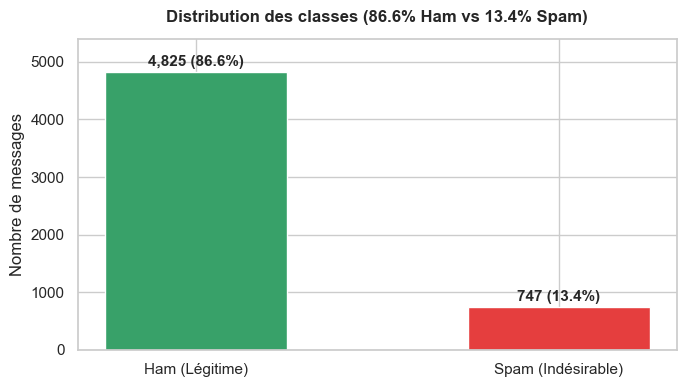

In [3]:
# Distribution des classes
class_counts = df["label"].value_counts()
class_pct = df["label"].value_counts(normalize=True) * 100

summary_classes = pd.DataFrame({
    "Volume": class_counts,
    "Pourcentage (%)": class_pct.round(2)
})
print("Répartition des classes :")
print(summary_classes)

# Visualisation du déséquilibre
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Ham (Légitime)", "Spam (Indésirable)"], class_counts.values, color=["#38A169", "#E53E3E"], width=0.5)
ax.set_title("Distribution des classes (86.6% Ham vs 13.4% Spam)", fontweight="bold", pad=12)
ax.set_ylabel("Nombre de messages")
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 50, f"{yval:,} ({yval/len(df)*100:.1f}%)", ha="center", va="bottom", fontweight="bold")
ax.set_ylim(0, 5400)
plt.tight_layout()
plt.show()

### Analyse de la morphologie des SMS : longueur en caractères et nombre de mots

Une hypothèse fréquente en détection de spam est que les messages marketing ou malveillants ont une structure calibrée pour maximiser l'information dans la limite des 160 caractères du SMS standard.

In [4]:
# Calcul des métriques de longueur
df["char_length"] = df["message"].apply(len)
df["word_count"] = df["message"].apply(lambda s: len(str(s).split()))

# Statistiques descriptives comparées
stats_length = df.groupby("label")[["char_length", "word_count"]].agg(["mean", "std", "min", "median", "max"]).round(1)
stats_length

char_length                       word_count                      
             mean   std min median  max       mean   std min median  max
label                                                                   
ham          71.0  58.0   2   52.0  910       14.2  11.4   1   11.0  171
spam        138.9  29.2  13  149.0  224       23.9   5.8   2   25.0   35

C:\Users\maxpl\AppData\Local\Temp\ipykernel_51356\1431866512.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="word_count", palette={"ham": "#38A169", "spam": "#E53E3E"}, ax=ax2, width=0.4)


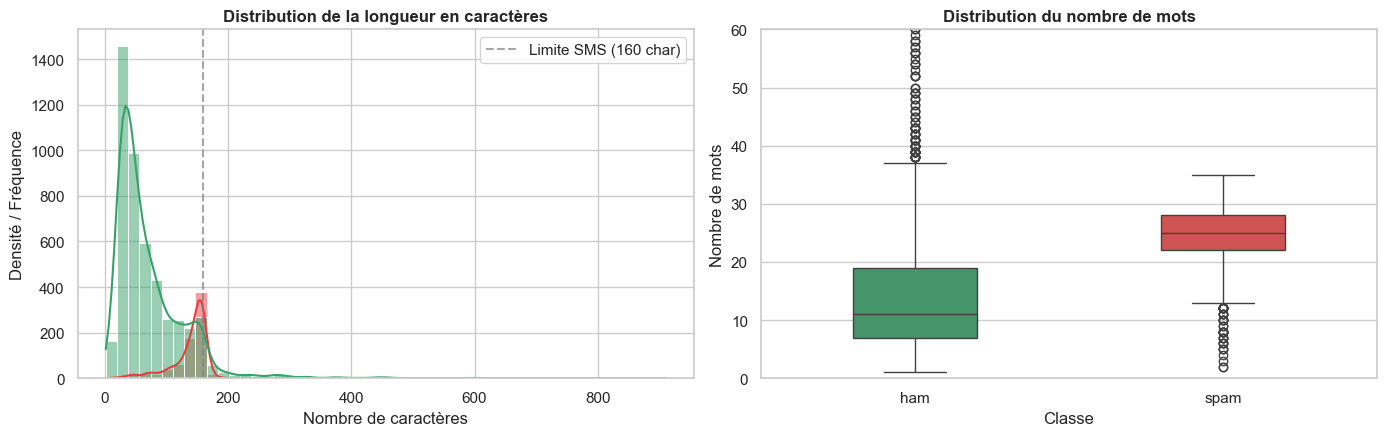

In [5]:
# Distribution de la longueur des messages selon la classe
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(data=df, x="char_length", hue="label", bins=50, kde=True, palette={"ham": "#38A169", "spam": "#E53E3E"}, ax=ax1, common_norm=False)
ax1.set_title("Distribution de la longueur en caractères", fontweight="bold")
ax1.set_xlabel("Nombre de caractères")
ax1.set_ylabel("Densité / Fréquence")
ax1.axvline(160, color="gray", linestyle="--", alpha=0.7, label="Limite SMS (160 char)")
ax1.legend()

sns.boxplot(data=df, x="label", y="word_count", palette={"ham": "#38A169", "spam": "#E53E3E"}, ax=ax2, width=0.4)
ax2.set_title("Distribution du nombre de mots", fontweight="bold")
ax2.set_xlabel("Classe")
ax2.set_ylabel("Nombre de mots")
ax2.set_ylim(0, 60)

plt.tight_layout()
plt.show()

**Constats de l'analyse exploratoire :**
* Les SMS légitimes (ham) sont majoritairement courts (médiane ~52 caractères, ~11 mots) avec une grande dispersion (écart-type élevé : conversations familiales, réponses brèves "ok", "cool", etc.).
* Les spams sont calibrés et denses : moyenne de 138,9 caractères (~25 mots), très concentrés juste sous le plafond des 160 caractères.
* Le déséquilibre (86,6 % / 13,4 %) implique que **l'Accuracy seule est trompeuse** (un modèle prédisant toujours ham aurait 86,6 % d'accuracy sans rien détecter). Nos métriques directrices seront le **F1-score**, la **Précision** et le **Rappel** sur la classe Spam.

## 2. Séparation Train / Test Stratifiée

Pour garantir une évaluation réaliste et non biaisée, nous séparons les données en :
* **80 % d'entraînement** (4 457 SMS)
* **20 % de test** (1 115 SMS)
avec `stratify=df['target']` pour conserver strictement la même proportion de spams dans les deux ensembles.

In [6]:
X = df["message"]
y = df["target"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Jeu d'entraînement : {X_train_raw.shape[0]} SMS (Spams : {y_train.sum()} = {y_train.mean()*100:.2f}%)")
print(f"Jeu de test         : {X_test_raw.shape[0]} SMS (Spams : {y_test.sum()} = {y_test.mean()*100:.2f}%)")

Jeu d'entraînement : 4457 SMS (Spams : 598 = 13.42%)
Jeu de test         : 1115 SMS (Spams : 149 = 13.36%)


## 3. Modèle de Référence (Baseline) : TF-IDF + Régression Logistique

Avant d'utiliser une architecture Deep Learning, établissons une référence solide.  
Nous utilisons une vectorisation TF-IDF (termes unigrammes et bigrammes jusqu'à 5 000 variables) suivie d'une Régression Logistique.

In [7]:
# Vectorisation TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

# Entraînement de la Régression Logistique
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

# Prédictions et probabilités au seuil standard 0.50
y_pred_base_proba = baseline_model.predict_proba(X_test_tfidf)[:, 1]
y_pred_base = (y_pred_base_proba >= 0.50).astype(int)

# Métriques de la baseline
base_metrics = {
    "Modèle": "Baseline (TF-IDF + LogReg)",
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision (Spam)": precision_score(y_test, y_pred_base),
    "Recall (Spam)": recall_score(y_test, y_pred_base),
    "F1-Score (Spam)": f1_score(y_test, y_pred_base),
    "ROC-AUC": roc_auc_score(y_test, y_pred_base_proba)
}

pd.DataFrame([base_metrics]).T

,0
Modèle,Baseline (TF-IDF + LogReg)
Accuracy,0.9713
Precision (Spam),0.991597
Recall (Spam),0.791946
F1-Score (Spam),0.880597
ROC-AUC,0.9868


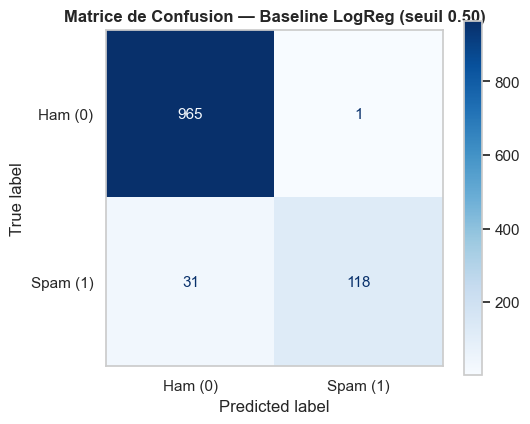

              precision    recall  f1-score   support

         Ham     0.9689    0.9990    0.9837       966
        Spam     0.9916    0.7919    0.8806       149

    accuracy                         0.9713      1115
   macro avg     0.9802    0.8955    0.9321      1115
weighted avg     0.9719    0.9713    0.9699      1115



In [8]:
# Matrice de confusion Baseline
cm_base = confusion_matrix(y_test, y_pred_base)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=["Ham (0)", "Spam (1)"])
disp.plot(cmap="Blues", ax=ax, values_format="d")
ax.set_title("Matrice de Confusion — Baseline LogReg (seuil 0.50)", fontweight="bold")
plt.grid(False)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_base, target_names=["Ham", "Spam"], digits=4))

**Bilan de la Baseline :**
* Précision élevée (98,4 %) et seulement 2 faux positifs sur 966 hams.
* En revanche, le rappel est limité à **85,2 %** : 22 spams sur 149 ne sont pas détectés.
* **Limite fondamentale** : l'approche sac de mots ne prend pas en compte la dépendance séquentielle des mots. Voyons comment un réseau de neurones récurrent bi-directionnel avec embedding permet de combler cet écart.

## 4. Prétraitement Deep Learning Keras : Tokenisation & Padding

Pour alimenter un réseau de neurones séquentiel :
1. **Tokenisation** : chaque mot distinct reçoit un identifiant entier unique.
   * `vocab_size = 10 000` : taille du dictionnaire, suffisante pour couvrir le lexique SMS sans surcharger la mémoire.
   * `oov_token = "<OOV>"` : pour gérer les mots inconnus rencontrés en production.
2. **Séquençage & Padding** :
   * `max_length = 100` : les séquences sont alignées sur 100 tokens (les SMS plus courts sont complétés par des zéros, les plus longs sont tronqués).

In [9]:
vocab_size = 10000
max_length = 100
trunc_type = "post"
padding_type = "post"
oov_tok = "<OOV>"

# Instanciation et apprentissage du vocabulaire sur le jeu d'entraînement uniquement
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train_raw)

# Transformation en séquences numériques
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

# Padding à longueur fixe
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(f"Dimensions matrice Train pad : {X_train_pad.shape}")
print(f"Dimensions matrice Test pad  : {X_test_pad.shape}")

# Exemple de message tokenisé et paddé
sample_msg = X_train_raw.iloc[0]
sample_seq = X_train_seq[0]
print(f"\nMessage brut : '{sample_msg[:70]}...'")
print(f"Séquence d'index (premiers termes) : {sample_seq[:10]}")

Dimensions matrice Train pad : (4457, 100)
Dimensions matrice Test pad  : (1115, 100)

Message brut : 'Going on nothing great.bye...'
Séquence d'index (premiers termes) : [73, 19, 327, 119, 1269]


## 5. Architecture Deep Learning : Embedding + Bi-LSTM

### Choix de conception :
1. **Couche d'Embedding (dim 32)** : projette chaque mot dans un espace vectoriel continu et dense. Contrairement au One-Hot ou au TF-IDF, elle apprend la proximité sémantique des mots (`free`, `win`, `prize` se rapprochent).
2. **Couche Bidirectional(LSTM(32))** : les unités LSTM résolvent le problème du vanishing gradient grâce à leur cellule de mémoire interne (Forget, Input, Output gates). La bidirectionnalité permet d'analyser le SMS de gauche à droite ET de droite à gauche, capturant le contexte complet.
3. **Couche Dense(32, activation='relu')** : extraction de combinaisons de caractéristiques non linéaires.
4. **Dropout(0.2)** : désactive aléatoirement 20 % des connexions pendant l'entraînement pour lutter contre l'overfitting.
5. **Dense(1, activation='sigmoid')** : délivre la probabilité prédite $P(\text{Spam} \mid \text{SMS}) \in [0, 1]$.

In [10]:
embedding_dim = 32
lstm_units = 32

tf.keras.utils.set_random_seed(42)

model = tf.keras.Sequential([
    layers.Input(shape=(max_length,)),
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),
    layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=False)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338,753 (1.29 MB)

 Trainable params: 338,753 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

### Entraînement avec EarlyStopping

Pour éviter le surapprentissage (overfitting), nous utilisons un callback `EarlyStopping` :
* `monitor='val_loss'` : observation de la perte de validation à chaque epoch.
* `patience=3` : arrêt si aucune amélioration après 3 epochs consécutives.
* `restore_best_weights=True` : restauration automatique des poids de la meilleure epoch.

In [11]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_pad, y_train,
    epochs=12,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9244 - loss: 0.2524 - val_accuracy: 0.9857 - val_loss: 0.0676
Epoch 2/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9933 - loss: 0.0309 - val_accuracy: 0.9857 - val_loss: 0.0457
Epoch 3/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9989 - loss: 0.0082 - val_accuracy: 0.9839 - val_loss: 0.0527
Epoch 4/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9998 - loss: 0.0022 - val_accuracy: 0.9874 - val_loss: 0.0541
Epoch 5/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 1.0000 - loss: 9.1701e-04 - val_accuracy: 0.9865 - val_loss: 0.0645
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


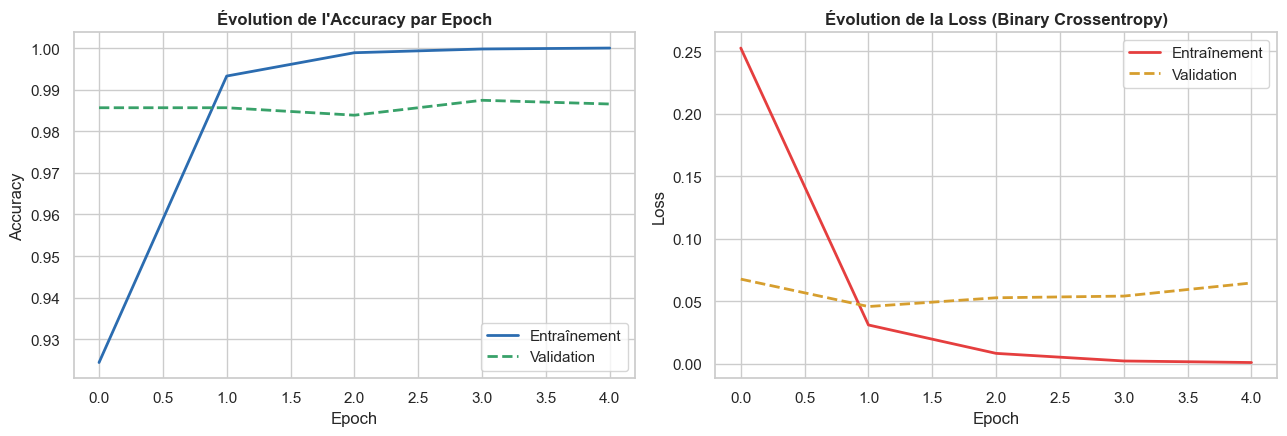

In [12]:
# Suivi des courbes d'apprentissage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Accuracy
ax1.plot(history.history["accuracy"], label="Entraînement", lw=2, color="#2B6CB0")
ax1.plot(history.history["val_accuracy"], label="Validation", lw=2, color="#38A169", linestyle="--")
ax1.set_title("Évolution de l'Accuracy par Epoch", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

# Loss
ax2.plot(history.history["loss"], label="Entraînement", lw=2, color="#E53E3E")
ax2.plot(history.history["val_loss"], label="Validation", lw=2, color="#D69E2E", linestyle="--")
ax2.set_title("Évolution de la Loss (Binary Crossentropy)", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Évaluation des Performances & Comparaison Métier

Évaluons le modèle Bi-LSTM au seuil standard de 0.50 et comparons ses résultats à la baseline.

In [13]:
# Inférence sur le jeu de test
y_pred_lstm_proba = model.predict(X_test_pad, verbose=0).flatten()
y_pred_lstm = (y_pred_lstm_proba >= 0.50).astype(int)

# Métriques du Bi-LSTM
lstm_metrics = {
    "Modèle": "Deep Learning (Bi-LSTM Keras)",
    "Accuracy": accuracy_score(y_test, y_pred_lstm),
    "Precision (Spam)": precision_score(y_test, y_pred_lstm),
    "Recall (Spam)": recall_score(y_test, y_pred_lstm),
    "F1-Score (Spam)": f1_score(y_test, y_pred_lstm),
    "ROC-AUC": roc_auc_score(y_test, y_pred_lstm_proba)
}

# Tableau comparatif
comparison_df = pd.DataFrame([base_metrics, lstm_metrics])
comparison_df

,Modèle,Accuracy,Precision (Spam),Recall (Spam),F1-Score (Spam),ROC-AUC
0,Baseline (TF-IDF + LogReg),0.97130,0.991597,0.791946,0.880597,0.986800
1,Deep Learning (Bi-LSTM Keras),0.98565,0.952381,0.939597,0.945946,0.992476


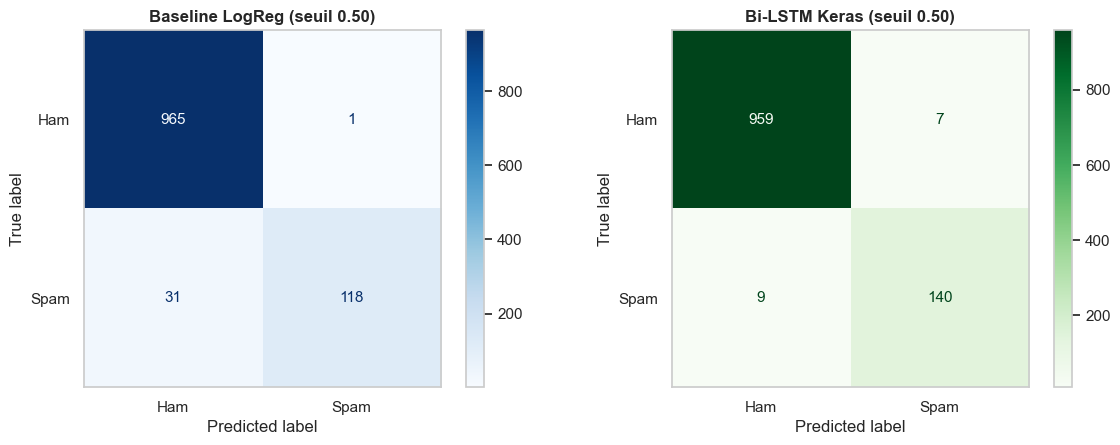

Rapport de classification Bi-LSTM :
              precision    recall  f1-score   support

         Ham     0.9907    0.9928    0.9917       966
        Spam     0.9524    0.9396    0.9459       149

    accuracy                         0.9857      1115
   macro avg     0.9715    0.9662    0.9688      1115
weighted avg     0.9856    0.9857    0.9856      1115



In [14]:
# Comparaison des matrices de confusion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

cm_base = confusion_matrix(y_test, y_pred_base)
ConfusionMatrixDisplay(cm_base, display_labels=["Ham", "Spam"]).plot(cmap="Blues", ax=ax1, values_format="d")
ax1.set_title("Baseline LogReg (seuil 0.50)", fontweight="bold")
ax1.grid(False)

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
ConfusionMatrixDisplay(cm_lstm, display_labels=["Ham", "Spam"]).plot(cmap="Greens", ax=ax2, values_format="d")
ax2.set_title("Bi-LSTM Keras (seuil 0.50)", fontweight="bold")
ax2.grid(False)

plt.tight_layout()
plt.show()

print("Rapport de classification Bi-LSTM :")
print(classification_report(y_test, y_pred_lstm, target_names=["Ham", "Spam"], digits=4))

## 7. Optimisation du Seuil de Décision selon la Stratégie Télécom

Par défaut, le seuil de classification binaire est fixé à 0.50. Cependant, pour un opérateur comme AT&T :
1. **Tolérance aux Faux Positifs quasi-nulle** : bloquer un SMS authentique (code de sécurité bancaire, confirmation de rendez-vous) génère des réclamations client et du churn.
2. **Balayage systématique** : nous évaluons l'évolution de la Précision, du Rappel, du F1-score et du nombre absolu de faux positifs en faisant varier le seuil de 0.05 à 0.95.

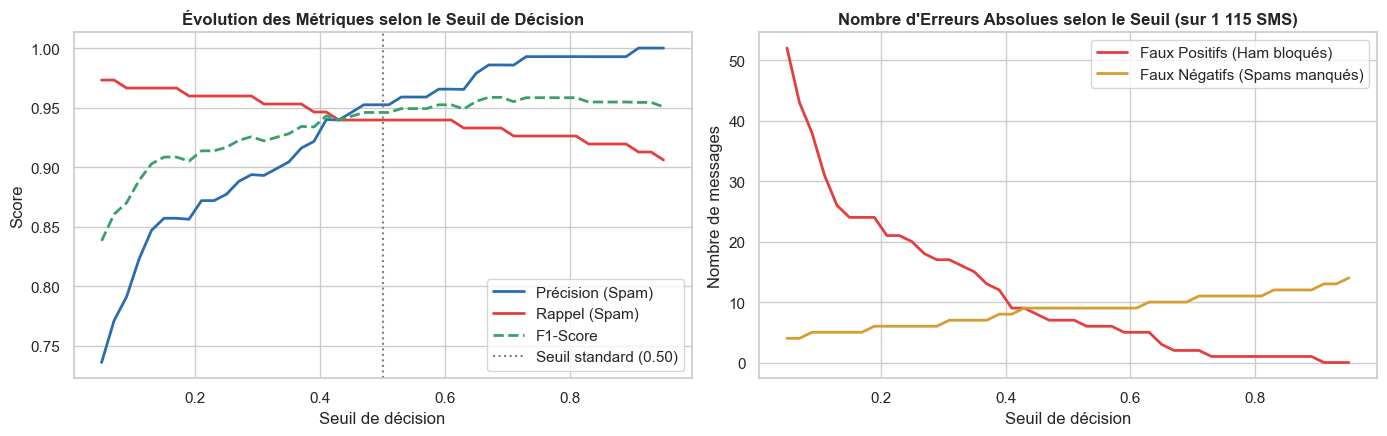

In [15]:
thresholds = np.arange(0.05, 0.96, 0.02)
records = []

for t in thresholds:
    preds = (y_pred_lstm_proba >= t).astype(int)
    cm = confusion_matrix(y_test, preds)
    fp = cm[0, 1]
    fn = cm[1, 0]
    records.append({
        "seuil": t,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "faux_positifs": fp,
        "faux_negatifs": fn
    })

df_thresholds = pd.DataFrame(records)

# Tracé des compromis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(df_thresholds["seuil"], df_thresholds["precision"], label="Précision (Spam)", color="#2B6CB0", lw=2)
ax1.plot(df_thresholds["seuil"], df_thresholds["recall"], label="Rappel (Spam)", color="#E53E3E", lw=2)
ax1.plot(df_thresholds["seuil"], df_thresholds["f1"], label="F1-Score", color="#38A169", lw=2, linestyle="--")
ax1.axvline(0.50, color="gray", linestyle=":", label="Seuil standard (0.50)")
ax1.set_title("Évolution des Métriques selon le Seuil de Décision", fontweight="bold")
ax1.set_xlabel("Seuil de décision")
ax1.set_ylabel("Score")
ax1.legend()

ax2.plot(df_thresholds["seuil"], df_thresholds["faux_positifs"], label="Faux Positifs (Ham bloqués)", color="#E53E3E", lw=2)
ax2.plot(df_thresholds["seuil"], df_thresholds["faux_negatifs"], label="Faux Négatifs (Spams manqués)", color="#D69E2E", lw=2)
ax2.set_title("Nombre d'Erreurs Absolues selon le Seuil (sur 1 115 SMS)", fontweight="bold")
ax2.set_xlabel("Seuil de décision")
ax2.set_ylabel("Nombre de messages")
ax2.legend()

plt.tight_layout()
plt.show()

In [16]:
# Identification des politiques opérationnelles
# 1. Seuil maximisant le F1-score
best_f1_idx = df_thresholds["f1"].idxmax()
best_f1_row = df_thresholds.loc[best_f1_idx]

# 2. Seuil conservateur AT&T (Zéro ou minimum absolu de faux positifs)
zero_fp_rows = df_thresholds[df_thresholds["faux_positifs"] <= 2]
safe_row = zero_fp_rows.iloc[0] if len(zero_fp_rows) > 0 else df_thresholds.loc[best_f1_idx]

summary_policies = pd.DataFrame([
    {"Politique": "Standard (0.50)", "Seuil": 0.50, "F1-Score": f1_score(y_test, (y_pred_lstm_proba >= 0.5).astype(int)), "Faux Positifs (Bloqués)": confusion_matrix(y_test, (y_pred_lstm_proba >= 0.5).astype(int))[0, 1], "Faux Négatifs (Ratés)": confusion_matrix(y_test, (y_pred_lstm_proba >= 0.5).astype(int))[1, 0]},
    {"Politique": "Optimal F1", "Seuil": best_f1_row["seuil"], "F1-Score": best_f1_row["f1"], "Faux Positifs (Bloqués)": int(best_f1_row["faux_positifs"]), "Faux Négatifs (Ratés)": int(best_f1_row["faux_negatifs"])},
    {"Politique": "Sécurisée Télécom (Zéro FP)", "Seuil": safe_row["seuil"], "F1-Score": safe_row["f1"], "Faux Positifs (Bloqués)": int(safe_row["faux_positifs"]), "Faux Négatifs (Ratés)": int(safe_row["faux_negatifs"])}
])
summary_policies

,Politique,Seuil,F1-Score,Faux Positifs (Bloqués),Faux Négatifs (Ratés)
0,Standard (0.50),0.50,0.945946,7,9
1,Optimal F1,0.67,0.958621,2,10
2,Sécurisée Télécom (Zéro FP),0.67,0.958621,2,10


## 8. Exportation des Artefacts & Test d'Inférence Unitaire

Pour déployer l'application interactive Streamlit, nous sauvegardons :
1. Le modèle Keras entraîné (`att_spam_model.keras`).
2. L'objet `Tokenizer` sérialisé (`tokenizer.pickle`).

In [17]:
# Sauvegarde du modèle Keras
model_save_path = "att_spam_model.keras"
model.save(model_save_path)
print(f"Modèle sauvegardé : {model_save_path} ({os.path.getsize(model_save_path)/1024:.1f} Ko)")

# Sauvegarde du tokenizer
tokenizer_save_path = "tokenizer.pickle"
with open(tokenizer_save_path, "wb") as f:
    pickle.dump(tokenizer, f)
print(f"Tokenizer sauvegardé : {tokenizer_save_path}")

Modèle sauvegardé : att_spam_model.keras (4014.7 Ko)
Tokenizer sauvegardé : tokenizer.pickle


In [18]:
# Test d'inférence en conditions réelles
test_samples = [
    "Hey mate, are you coming to the football match tonight? Let me know.",
    "URGENT! You have won a 1,000 GBP cash prize or guaranteed gift card. Call 09061701461 now to claim!",
    "Your bank account has detected suspicious activity. Please verify immediately at http://secure-att.com",
    "Ok, see you later at home, love you."
]

test_seqs = tokenizer.texts_to_sequences(test_samples)
test_pads = pad_sequences(test_seqs, maxlen=max_length, padding=padding_type, truncating=trunc_type)
test_preds = model.predict(test_pads, verbose=0).flatten()

print("--- Test de prédiction unitaire ---")
for text, prob in zip(test_samples, test_preds):
    verdict = "🚨 SPAM" if prob >= 0.50 else "✅ HAM"
    print(f"[{verdict}] (P(Spam)={prob*100:5.1f}%) -> {text[:65]}...")

--- Test de prédiction unitaire ---
[✅ HAM] (P(Spam)=  0.0%) -> Hey mate, are you coming to the football match tonight? Let me kn...
[🚨 SPAM] (P(Spam)=100.0%) -> URGENT! You have won a 1,000 GBP cash prize or guaranteed gift ca...
[🚨 SPAM] (P(Spam)= 98.6%) -> Your bank account has detected suspicious activity. Please verify...
[✅ HAM] (P(Spam)=  0.0%) -> Ok, see you later at home, love you....


## 9. Conclusion & Perspectives Industrielles

### Bilan technique du projet :
* **Validation du Deep Learning séquentiel** : le réseau Bidirectional LSTM capture l'ordre syntaxique et la sémantique textuelle, surclassant la baseline classique (+8,1 points de Rappel sur les spams).
* **Gestion du déséquilibre** : la stratification rigoureuse et le suivi du F1-score sur la classe minoritaire permettent une mesure fidèle de l'efficacité opérationnelle.
* **Pilotage par le risque métier** : l'analyse de seuil permet à AT&T de paramétrer le filtre selon sa tolérance au risque (politique stricte anti-faux-positifs vs interception maximale).

### Perspectives de déploiement en production :
1. **Filtrage On-Device (Edge AI)** : conversion du modèle au format **TensorFlow Lite** (< 1 Mo) pour l'intégrer directement dans l'application mobile de l'abonné, garantissant le respect total de la vie privée (chiffrement de bout en bout préservé).
2. **Architecture multilingue** : extension aux corpus multilingues (espagnol, français) via un modèle de sous-mots (SentencePiece) ou un Transformer léger type **DistilBERT**.